# Customer Churn Prediction

**IBM Telco Customer Churn — Complete Assignment**

This notebook is intentionally divided into small cells so each stage can be explained during the demo.

### Assignment flow
1. Data understanding & preparation
2. Exploratory Data Analysis (EDA)
3. Feature engineering
4. Decision Tree models
5. Bonus: class imbalance handling, hyperparameter tuning and Random Forest
6. Evaluation
7. Feature importance and tree interpretation
8. Save the complete preprocessing + model pipeline
9. Test an unseen customer

> **Data leakage principle:** The train/test split is performed before fitting preprocessing. The preprocessing is fitted only on training data and the same fitted pipeline is later reused for test and unseen customers.

## 1. Import libraries

This cell imports the Python libraries used throughout the project.

In [2]:
import sys
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

sys.path.append("../src")
from churn_pipeline import ChurnFeatureEngineer

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the dataset

We load the CSV into a Pandas DataFrame. A DataFrame is a table-like structure used to work with rows and columns of data.

In [15]:
df = pd.read_csv("../data/TelcoCustomerChurn.csv")

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
display(df.head())

Dataset loaded successfully.
Rows: 7043
Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Data structure and data types

We inspect the columns, their data types and the overall structure of the dataset.

In [4]:
print("Data types:")
display(df.dtypes.to_frame("Data Type"))

print("Dataset shape:", df.shape)
print("Column names:")
print(df.columns.tolist())

Data types:


,Data Type
customerID,str
gender,str
SeniorCitizen,int64
Partner,str
Dependents,str
tenure,int64
PhoneService,str
MultipleLines,str
InternetService,str
OnlineSecurity,str


Dataset shape: (7043, 21)
Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


## 4. Descriptive statistics

`describe(include="all")` gives a broad summary. For numeric columns it includes statistics such as mean and standard deviation; for categorical columns it includes count, unique, most frequent value and its frequency.

In [ ]:
display(df.describe(include="all").T)

## 5. Missing values, duplicates and identifier check

`customerID` is a unique identifier, so it should not be used as a predictive feature. `TotalCharges` contains blank values that will be handled safely inside the reusable preprocessing pipeline.

In [16]:
blank_total_charges = (df["TotalCharges"].astype(str).str.strip() == "").sum()

print("Blank TotalCharges:", blank_total_charges)
print("Duplicate rows:", df.duplicated().sum())
print("Unique customer IDs:", df["customerID"].nunique())
print("Total rows:", len(df))

Blank TotalCharges: 11
Duplicate rows: 0
Unique customer IDs: 7043
Total rows: 7043


## 6. Target variable: Churn

The target is what the model must predict: whether a customer churned (`Yes`) or did not churn (`No`).

In [17]:
target_counts = df["Churn"].value_counts()
target_pct = df["Churn"].value_counts(normalize=True).mul(100).round(2)

display(pd.DataFrame({
    "Customers": target_counts,
    "Percentage": target_pct
}))

,Customers,Percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


### Business insight

The dataset has about **26.5% churn** and **73.5% non-churn**. This is a class-imbalance problem.

A model that predicted `No Churn` for everyone would get roughly 73.5% accuracy but would identify **zero churners**. Therefore, accuracy alone is not enough; precision, recall and F1-score are important.

## 7. Churn distribution

First EDA visualization: the distribution of the target variable.

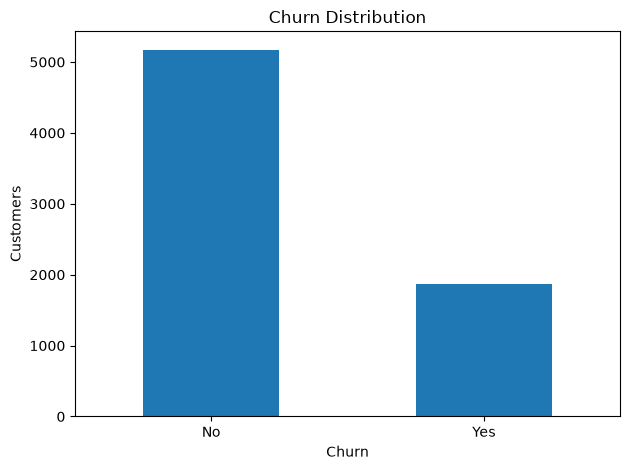

In [18]:
fig, ax = plt.subplots()
df["Churn"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Churn Distribution")
ax.set_xlabel("Churn")
ax.set_ylabel("Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Business insight:** Churn is a minority class, so the business should evaluate how well the model identifies actual churners rather than relying only on overall accuracy.

## 8. Churn by Contract

We calculate the percentage of customers who churn within each contract type.

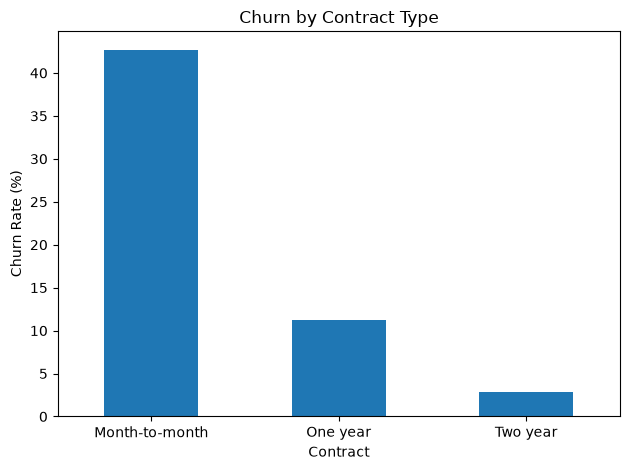

,Churn Rate (%)
Contract,
Month-to-month,42.7
One year,11.3
Two year,2.8


In [20]:
contract_churn = (
    pd.crosstab(df["Contract"], df["Churn"], normalize="index")["Yes"]
    .mul(100)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots()
contract_churn.plot(kind="bar", ax=ax)
ax.set_title("Churn by Contract Type")
ax.set_xlabel("Contract")
ax.set_ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(contract_churn.to_frame("Churn Rate (%)").round(1))

**Business insight:** Month-to-month customers have a much higher observed churn rate than one-year and two-year contract customers. Contract commitment is therefore an important segmentation variable for retention analysis.

## 9. Churn by Internet Service

We compare churn rates across internet-service categories.

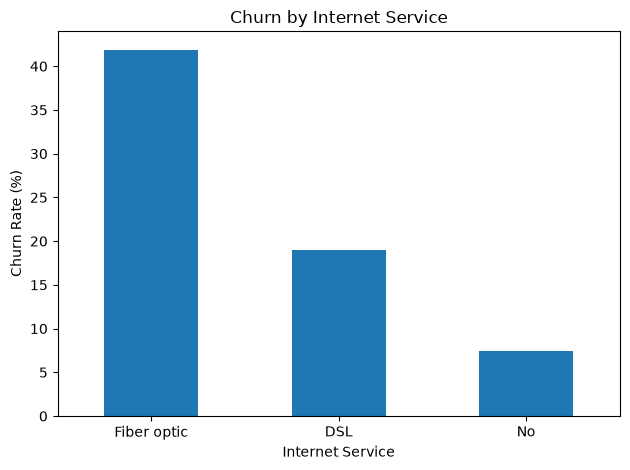

,Churn Rate (%)
InternetService,
Fiber optic,41.9
DSL,19.0
No,7.4


In [38]:
internet_churn = (
    pd.crosstab(df["InternetService"], df["Churn"], normalize="index")["Yes"]
    .mul(100)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots()
internet_churn.plot(kind="bar", ax=ax)
ax.set_title("Churn by Internet Service")
ax.set_xlabel("Internet Service")
ax.set_ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(internet_churn.to_frame("Churn Rate (%)").round(1))

**Business insight:** Fiber-optic customers show a higher observed churn rate than DSL and customers without internet service in this dataset. This is a useful segment for further investigation; the chart describes association, not causation.

## 10. Churn by Payment Method

We compare churn rates across payment methods.

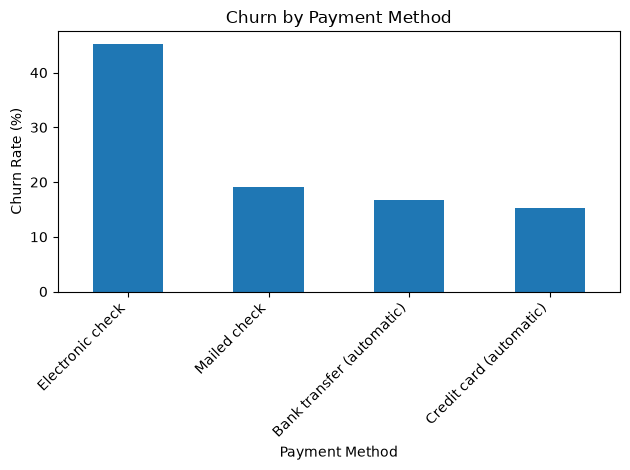

,Churn Rate (%)
PaymentMethod,
Electronic check,45.3
Mailed check,19.1
Bank transfer (automatic),16.7
Credit card (automatic),15.2


In [39]:
payment_churn = (
    pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index")["Yes"]
    .mul(100)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots()
payment_churn.plot(kind="bar", ax=ax)
ax.set_title("Churn by Payment Method")
ax.set_xlabel("Payment Method")
ax.set_ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(payment_churn.to_frame("Churn Rate (%)").round(1))

**Business insight:** Electronic-check customers have a higher observed churn rate than the other payment groups. Payment method can therefore be useful as a customer segment for retention analysis.

## 11. Churn by Tenure Group

Tenure is the number of months the customer has been with the company. We create groups only for EDA; this does not change the model input.

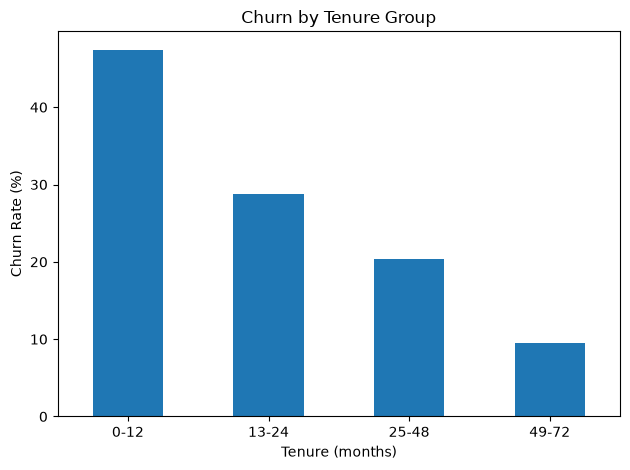

,Churn Rate (%)
TenureGroup,
0-12,47.4
13-24,28.7
25-48,20.4
49-72,9.5


In [21]:
eda = df.copy()
eda["TenureGroup"] = pd.cut(
    eda["tenure"],
    [-1, 12, 24, 48, 72],
    labels=["0-12", "13-24", "25-48", "49-72"]
)

tenure_churn = (
    pd.crosstab(eda["TenureGroup"], eda["Churn"], normalize="index")["Yes"]
    .mul(100)
)

fig, ax = plt.subplots()
tenure_churn.plot(kind="bar", ax=ax)
ax.set_title("Churn by Tenure Group")
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(tenure_churn.to_frame("Churn Rate (%)").round(1))

**Business insight:** Customers in their first 12 months have the highest observed churn rate, while long-tenure customers have a much lower observed churn rate. Early-life retention is therefore an important business segment.

## 12. Monthly Charges by Churn

This visualization compares the distribution of monthly charges for churned and non-churned customers.

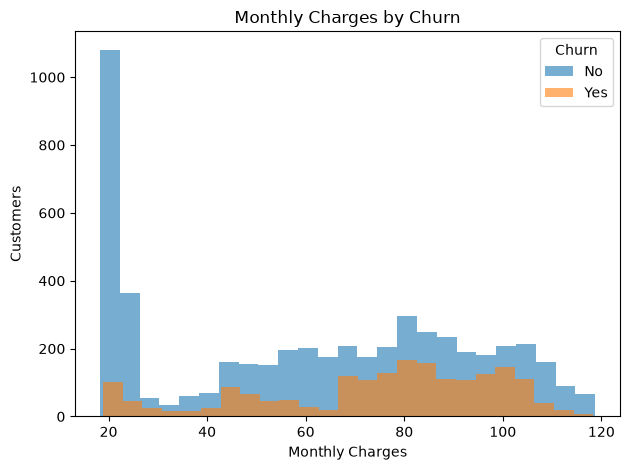

,Average Monthly Charges
Churn,
No,61.27
Yes,74.44


In [49]:
fig, ax = plt.subplots()

for label, group in df.groupby("Churn"):
    ax.hist(group["MonthlyCharges"], bins=25, alpha=0.6, label=label)

ax.set_title("Monthly Charges by Churn")
ax.set_xlabel("Monthly Charges")
ax.set_ylabel("Customers")
ax.legend(title="Churn")
plt.tight_layout()
plt.show()

display(df.groupby("Churn")["MonthlyCharges"].mean().to_frame("Average Monthly Charges").round(2))

**Business insight:** In this dataset, churned customers have higher average monthly charges than non-churned customers. This is an association and should be considered together with contract, services and tenure.

## 13. Prepare target and split the data

### Leakage prevention
We remove the target and identifier, then split the data **before fitting any preprocessing**. `random_state=42` makes the split reproducible, while `stratify=y` preserves the churn/non-churn proportion in train and test sets.

In [40]:
X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"].map({"No": 0, "Yes": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Training churn rate:", round(y_train.mean() * 100, 2), "%")
print("Testing churn rate:", round(y_test.mean() * 100, 2), "%")

Training shape: (4930, 19)
Testing shape: (2113, 19)
Training churn rate: 26.53 %
Testing churn rate: 26.55 %


**Demo sentence:** “To avoid data leakage, I split the data first and fit preprocessing only on the training data. The same fitted preprocessing is then reused for the test data and new unseen customers.”

## 14. Feature engineering

We add two meaningful features inside a reusable transformer:

- **AvgMonthlySpend** = `TotalCharges / tenure` (with zero-tenure protected from division by zero)
- **NumOptionalServices** = count of optional services marked `Yes`

Putting feature engineering inside the Pipeline ensures the exact same logic is applied during training, testing and API prediction.

In [41]:
feature_engineer = ChurnFeatureEngineer()

X_train_engineered = feature_engineer.fit_transform(X_train)
display(X_train_engineered[
    ["tenure", "TotalCharges", "AvgMonthlySpend", "NumOptionalServices"]
].head())

,tenure,TotalCharges,AvgMonthlySpend,NumOptionalServices
5557,5,384.25,76.850000,1.0
2270,3,220.95,73.650000,2.0
6930,3,216.75,72.250000,0.0
2257,60,4847.05,80.784167,4.0
898,12,1120.95,93.412500,4.0


**Business insight:** Average monthly spend summarizes cumulative charges relative to customer tenure, while the optional-service count summarizes the breadth of services a customer uses. Both can provide additional behavioral/service context.

## 15. Build leakage-safe preprocessing pipeline

Numeric features use median imputation. Categorical features use most-frequent imputation followed by one-hot encoding. `handle_unknown="ignore"` allows the saved pipeline to process a future category that was not present during training.

In [42]:
num = [
    "SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges",
    "AvgMonthlySpend", "NumOptionalServices"
]

cat = [
    c for c in X.columns
    if c not in ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
]

pre = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), cat)
])

def make_tree(**kwargs):
    return Pipeline([
        ("features", ChurnFeatureEngineer()),
        ("preprocess", pre),
        ("model", DecisionTreeClassifier(random_state=42, **kwargs))
    ])

print("Numeric features:", num)
print("Categorical features:", cat)

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'NumOptionalServices']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 16. Train Decision Tree A

First required Decision Tree configuration: `max_depth=5`.

In [43]:
tree_a = make_tree(max_depth=5)
tree_a.fit(X_train, y_train)
print("Decision Tree A trained.")

Decision Tree A trained.


## 17. Train Decision Tree B

Second required Decision Tree configuration: `max_depth=10` and `min_samples_split=10`.

In [24]:
tree_b = make_tree(max_depth=10, min_samples_split=10)
tree_b.fit(X_train, y_train)
print("Decision Tree B trained.")

Decision Tree B trained.


## 18. Bonus: balanced Decision Tree

Because churn is a minority class, `class_weight="balanced"` gives additional importance to the minority class during training.

In [25]:
balanced_tree = make_tree(max_depth=5, class_weight="balanced")
balanced_tree.fit(X_train, y_train)
print("Balanced Decision Tree trained.")

Balanced Decision Tree trained.


## 19. Compare the required Decision Trees

We evaluate accuracy, precision, recall and F1 on the untouched test set.

In [26]:
def score_model(name, model):
    predictions = model.predict(X_test)
    return [
        name,
        accuracy_score(y_test, predictions),
        precision_score(y_test, predictions, zero_division=0),
        recall_score(y_test, predictions, zero_division=0),
        f1_score(y_test, predictions, zero_division=0)
    ]

required_results = pd.DataFrame(
    [
        score_model("Decision Tree A", tree_a),
        score_model("Decision Tree B", tree_b),
        score_model("Balanced Decision Tree", balanced_tree)
    ],
    columns=["Model", "Accuracy", "Precision", "Recall", "F1"]
)

display(required_results.round(4))

,Model,Accuracy,Precision,Recall,F1
0,Decision Tree A,0.7937,0.6138,0.6007,0.6072
1,Decision Tree B,0.7582,0.5488,0.5009,0.5238
2,Balanced Decision Tree,0.6976,0.4615,0.8342,0.5943


### How to interpret the metrics

- **Accuracy:** percentage of all predictions that are correct.
- **Precision:** among customers predicted to churn, how many actually churned.
- **Recall:** among customers who actually churned, how many the model detected.
- **F1-score:** a combined measure balancing precision and recall.

For a retention use case, recall can be important because missing a customer who will churn may mean losing the opportunity to intervene. Precision also matters because unnecessary retention actions consume business resources.

## 20. Bonus: Hyperparameter tuning

`GridSearchCV` tests multiple Decision Tree configurations using cross-validation. We optimize for **F1-score**, which balances precision and recall.

In [45]:
tuned_tree = make_tree()

param_grid = {
    "model__max_depth": [4, 5, 7, 10],
    "model__min_samples_split": [2, 10],
    "model__class_weight": [None, "balanced"]
}

grid = GridSearchCV(
    tuned_tree, param_grid=param_grid, cv=3, scoring="f1", n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best cross-validation F1:", round(grid.best_score_, 4))

Best parameters: {'model__class_weight': 'balanced', 'model__max_depth': 4, 'model__min_samples_split': 2}
Best cross-validation F1: 0.6006


**Bonus point:** Hyperparameter tuning systematically searches configurations rather than selecting tree settings manually.

## 21. Bonus: Random Forest comparison

Random Forest combines many Decision Trees. It is included as an additional model for comparison; the assignment's required model remains Decision Tree.

In [28]:
random_forest = Pipeline([
    ("features", ChurnFeatureEngineer()),
    ("preprocess", pre),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

random_forest.fit(X_train, y_train)
print("Random Forest trained.")

Random Forest trained.


## 22. Full model comparison

This table compares both required Decision Trees and the bonus models.

In [29]:
results = pd.DataFrame(
    [
        score_model("Decision Tree A", tree_a),
        score_model("Decision Tree B", tree_b),
        score_model("Balanced Decision Tree", balanced_tree),
        score_model("Tuned Decision Tree", grid.best_estimator_),
        score_model("Random Forest (bonus)", random_forest)
    ],
    columns=["Model", "Accuracy", "Precision", "Recall", "F1"]
)

display(results.round(4))

,Model,Accuracy,Precision,Recall,F1
0,Decision Tree A,0.7937,0.6138,0.6007,0.6072
1,Decision Tree B,0.7582,0.5488,0.5009,0.5238
2,Balanced Decision Tree,0.6976,0.4615,0.8342,0.5943
3,Tuned Decision Tree,0.7487,0.5183,0.7576,0.6155
4,Random Forest (bonus),0.7705,0.5603,0.6292,0.5928


### Model-selection explanation

The final required model is selected based on **test-set F1**, while still considering the precision/recall trade-off.

In this project, the tuned Decision Tree is selected when its test F1 is at least as high as the baseline Decision Tree A. The final selection is therefore based on a documented metric rather than a subjective ranking.

In [46]:
final_model = (
    grid.best_estimator_
    if results.loc[3, "F1"] >= results.loc[0, "F1"]
    else tree_a
)

print("Final model type:", type(final_model.named_steps["model"]).__name__)
print("Final test F1:", round(
    f1_score(y_test, final_model.predict(X_test)), 4
))

Final model type: DecisionTreeClassifier
Final test F1: 0.6155


## 23. Final evaluation

We generate the classification report and confusion matrix for the selected final model.

In [47]:
final_predictions = final_model.predict(X_test)

print(classification_report(
    y_test,
    final_predictions,
    target_names=["No Churn", "Churn"],
    zero_division=0
))

              precision    recall  f1-score   support

    No Churn       0.89      0.75      0.81      1552
       Churn       0.52      0.76      0.62       561

    accuracy                           0.75      2113
   macro avg       0.71      0.75      0.71      2113
weighted avg       0.79      0.75      0.76      2113



Confusion matrix:
[[1157  395]
 [ 136  425]]


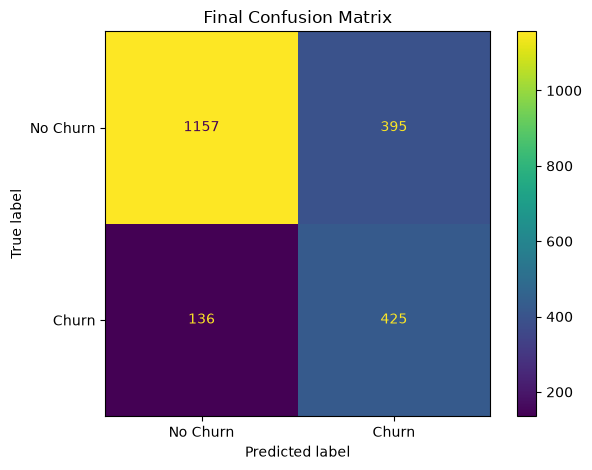

In [32]:
cm = confusion_matrix(y_test, final_predictions)

print("Confusion matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
).plot()

plt.title("Final Confusion Matrix")
plt.tight_layout()
plt.show()

### Confusion matrix interpretation

The four outcomes are:

- **True Negative:** correctly predicted No Churn
- **False Positive:** predicted Churn, but customer did not churn
- **False Negative:** predicted No Churn, but customer actually churned
- **True Positive:** correctly predicted Churn

For retention, false negatives are especially relevant because they represent actual churners the model failed to identify.

## 24. Feature importance

Decision Trees assign importance scores to features based on how much they reduce impurity across the tree.

In [33]:
tree_model = final_model.named_steps["model"]
preprocessor = final_model.named_steps["preprocess"]

feature_importance = pd.Series(
    tree_model.feature_importances_,
    index=preprocessor.get_feature_names_out()
).sort_values(ascending=False)

display(feature_importance.head(15).to_frame("Importance"))

,Importance
cat__Contract_Month-to-month,0.653257
num__tenure,0.113863
cat__InternetService_Fiber optic,0.108791
num__MonthlyCharges,0.038355
cat__OnlineBackup_No internet service,0.017692
cat__OnlineSecurity_No,0.016906
cat__TechSupport_No,0.015846
cat__PaymentMethod_Electronic check,0.015365
cat__Contract_One year,0.006364
num__TotalCharges,0.005829


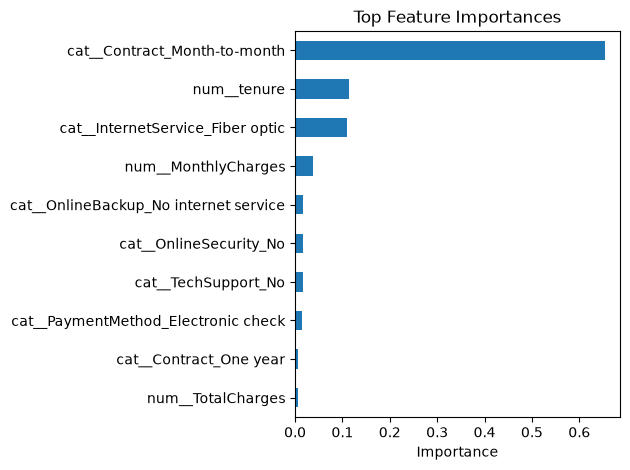

In [34]:
fig, ax = plt.subplots()
feature_importance.head(10).sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

**Interpretation:** The most important features are the variables the selected Decision Tree used most strongly to reduce impurity. Feature importance indicates contribution to the trained tree; it does not prove causation.

## 25. Decision Tree visualization

We display the first few levels of the final Decision Tree so the decision logic can be explained visually.

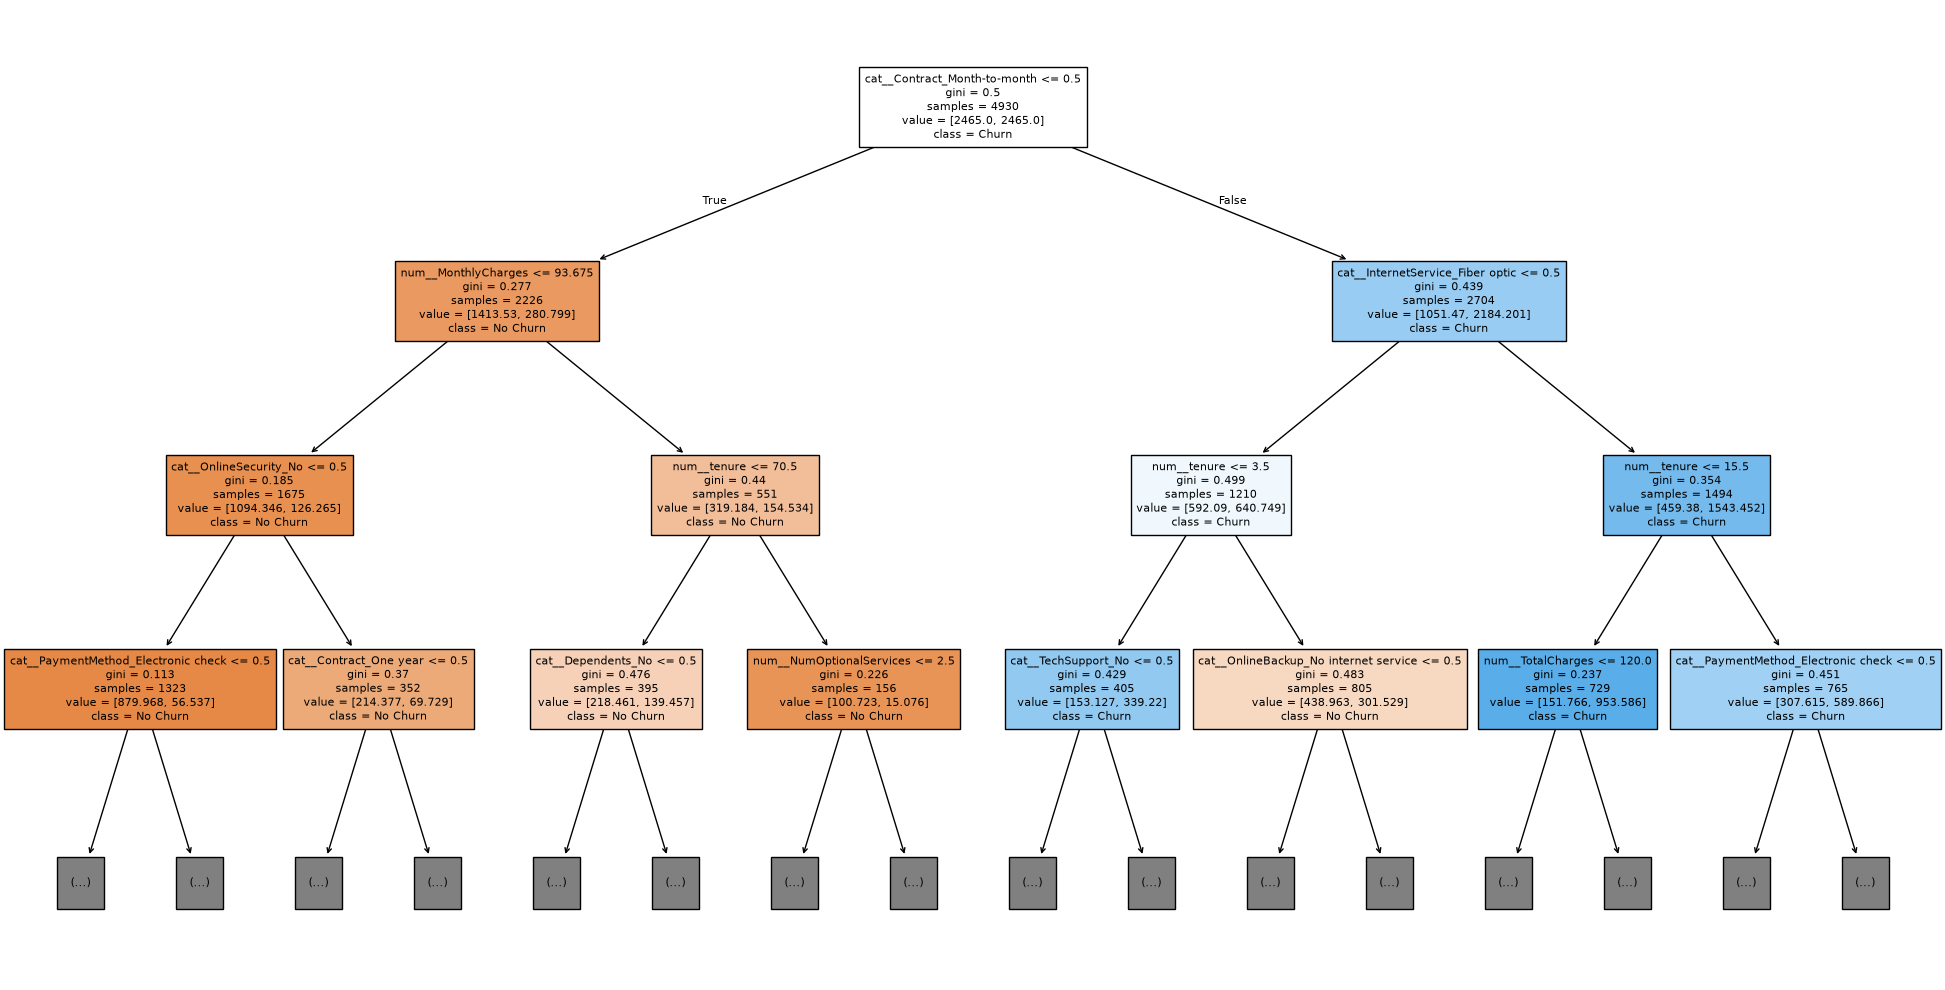

In [35]:
plt.figure(figsize=(20, 10))

plot_tree(
    tree_model,
    feature_names=preprocessor.get_feature_names_out(),
    class_names=["No Churn", "Churn"],
    filled=True,
    max_depth=3,
    fontsize=8
)

plt.tight_layout()
plt.show()

## 26. Save the complete pipeline

We save the **entire preprocessing + feature engineering + model pipeline**, not just the classifier. This is important because the API must apply exactly the same transformations to new customers.

In [36]:
model_path = "../model/churn_model.pkl"
joblib.dump(final_model, model_path)
print("Saved complete pipeline to:", model_path)

Saved complete pipeline to: ../model/churn_model.pkl


## 27. Test an unseen customer

This simulates a customer that was not part of the training/test dataset. Notice that we do not manually encode the values; the saved pipeline performs feature engineering, imputation and encoding consistently.

In [37]:
unseen_customer = X_test.iloc[[0]].copy()

prediction = int(final_model.predict(unseen_customer)[0])
probability = float(final_model.predict_proba(unseen_customer)[0, 1])

print("Prediction:", "Churn" if prediction else "No Churn")
print("Churn probability:", round(probability, 4))
display(unseen_customer)

Prediction: Churn
Churn probability: 0.7214


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
4994,Female,0,No,No,18,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,96.05,1740.7


## 28. Final checklist

### Assignment requirements
- [x] Data understanding and preparation
- [x] Missing values and duplicates
- [x] Numerical/categorical feature handling
- [x] 70:30 train/test split
- [x] `random_state=42`
- [x] Leakage-safe reusable preprocessing
- [x] 5+ EDA visualizations
- [x] Business insights
- [x] 2+ engineered features
- [x] 2 Decision Tree configurations
- [x] Accuracy, precision, recall, F1
- [x] Confusion matrix
- [x] Feature importance
- [x] Decision Tree visualization
- [x] Saved model/pipeline
- [x] Unseen-customer test
- [x] REST API available in `app.py`

### Bonus
- [x] Class imbalance handling
- [x] Hyperparameter tuning with GridSearchCV
- [x] Random Forest comparison